# ⚡ AI Energy Efficiency Monitoring — Exploratory Data Analysis

Deep-dive EDA covering:
- Target distribution & zero-reading analysis  
- Time patterns (hourly / daily / monthly / seasonal)  
- Building-type and meter-type breakdown  
- Weather correlation & missing-value profile  
- Outlier detection  
- Seasonal decomposition  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

DATA = r"d:\ashrae-energy-prediction\data"

train   = pd.read_csv(f"{DATA}/train.csv",           dtype={"building_id": "int16", "meter": "int8", "meter_reading": "float32"}, parse_dates=["timestamp"], nrows=2000000)
weather = pd.read_csv(f"{DATA}/weather_train.csv",   dtype={"site_id": "int8", "air_temperature": "float32", "cloud_coverage": "float32", "dew_temperature": "float32", "precip_depth_1_hr": "float32", "sea_level_pressure": "float32", "wind_direction": "float32", "wind_speed": "float32"}, parse_dates=["timestamp"])
meta    = pd.read_csv(f"{DATA}/building_metadata.csv", dtype={"site_id": "int8", "building_id": "int16", "square_feet": "int32"})

print(f"train   : {train.shape}")
print(f"weather : {weather.shape}")
print(f"meta    : {meta.shape}")
train.head(3)

train   : (2000000, 4)
weather : (139773, 9)
meta    : (1449, 6)


,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01,0.0
1,1,0,2016-01-01,0.0
2,2,0,2016-01-01,0.0


## 1 — Dataset Overview

In [2]:
print("=== train dtypes & nulls ===")
display(pd.DataFrame({"dtype": train.dtypes, "nulls": train.isnull().sum(),
                      "null_%": (train.isnull().mean()*100).round(2)}))

print("\n=== weather nulls (%) ===")
display((weather.isnull().mean()*100).round(2).to_frame("null_%"))

print("\n=== meta nulls ===")
display((meta.isnull().mean()*100).round(2).to_frame("null_%"))

=== train dtypes & nulls ===


,dtype,nulls,null_%
building_id,int16,0,0.0
meter,int8,0,0.0
timestamp,datetime64[ns],0,0.0
meter_reading,float32,0,0.0



=== weather nulls (%) ===


,null_%
site_id,0.00
timestamp,0.00
air_temperature,0.04
cloud_coverage,49.49
dew_temperature,0.08
precip_depth_1_hr,35.98
sea_level_pressure,7.60
wind_direction,4.48
wind_speed,0.22



=== meta nulls ===


,null_%
site_id,0.00
building_id,0.00
primary_use,0.00
square_feet,0.00
year_built,53.42
floor_count,75.50


## 2 — Meter Reading Distribution & Zero Analysis

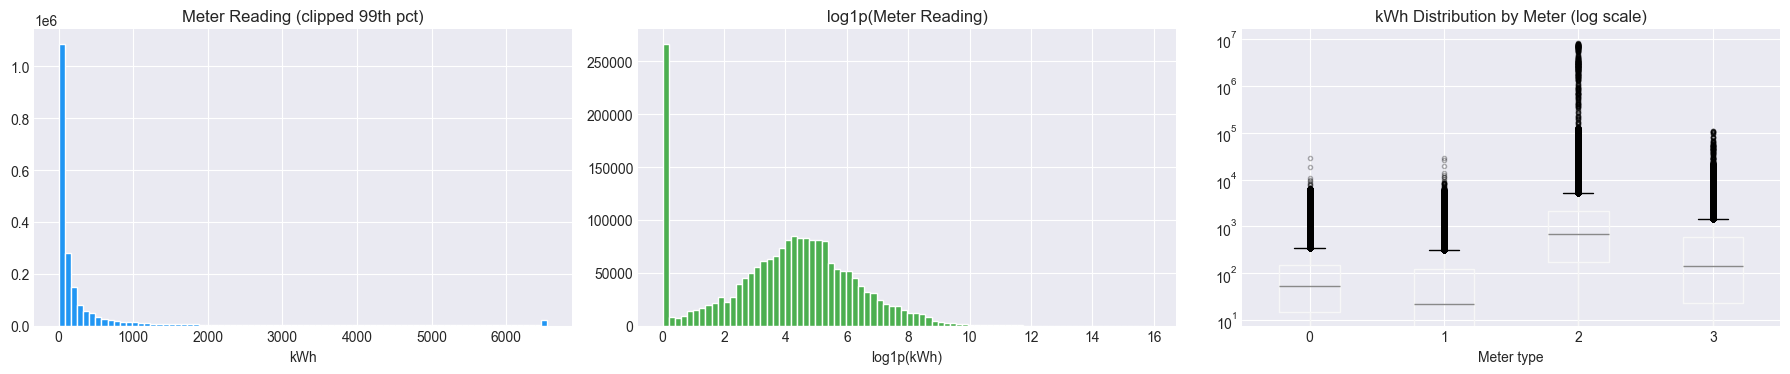

Zero readings : 12.6% of all records


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Raw
train["meter_reading"].clip(upper=train["meter_reading"].quantile(0.99)).hist(
    bins=80, ax=axes[0], color="#2196F3", edgecolor="white")
axes[0].set_title("Meter Reading (clipped 99th pct)", fontsize=12)
axes[0].set_xlabel("kWh")

# Log1p
np.log1p(train["meter_reading"]).hist(
    bins=80, ax=axes[1], color="#4CAF50", edgecolor="white")
axes[1].set_title("log1p(Meter Reading)", fontsize=12)
axes[1].set_xlabel("log1p(kWh)")

# Box per meter
train.boxplot(column="meter_reading", by="meter", ax=axes[2],
              flierprops=dict(marker=".", alpha=0.3))
axes[2].set_yscale("log")
axes[2].set_title("kWh Distribution by Meter (log scale)")
axes[2].set_xlabel("Meter type")
plt.suptitle("")
plt.tight_layout()
plt.show()

zero_pct = (train["meter_reading"] == 0).mean() * 100
print(f"Zero readings : {zero_pct:.1f}% of all records")

## 3 — Energy by Meter Type & Building Primary Use

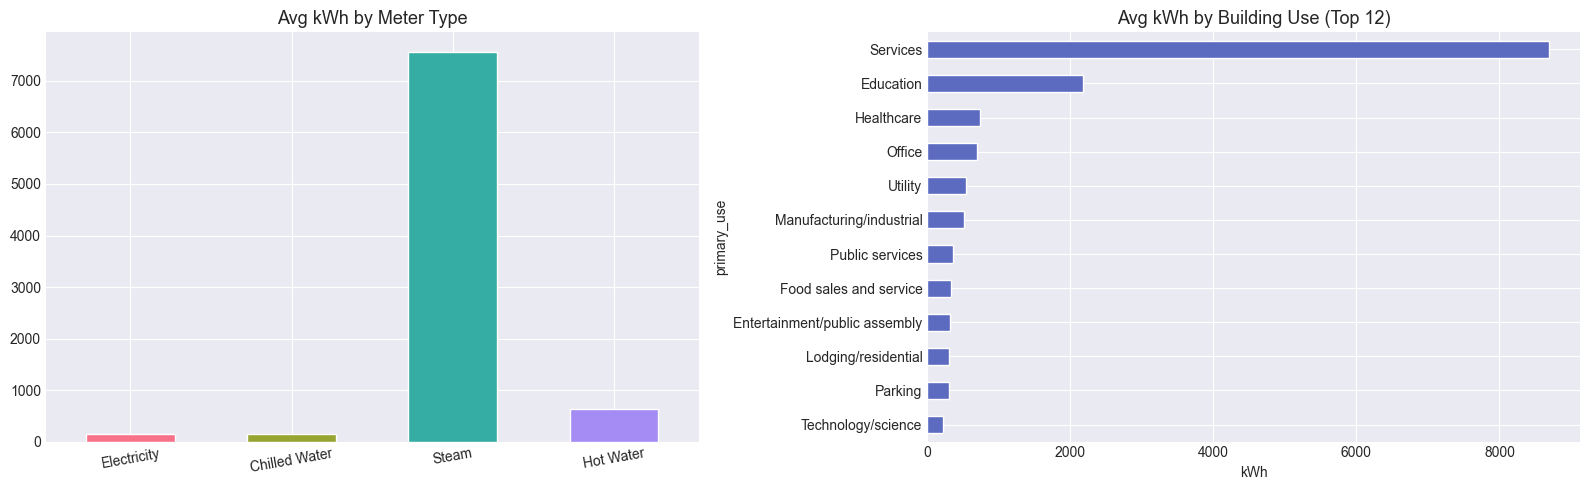

In [4]:
METER_LABELS = {0: "Electricity", 1: "Chilled Water", 2: "Steam", 3: "Hot Water"}
merged = train.merge(meta[["building_id", "primary_use"]], on="building_id", how="left")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

avg_meter = merged.groupby("meter")["meter_reading"].mean().rename(index=METER_LABELS)
avg_meter.plot(kind="bar", ax=axes[0], color=sns.color_palette("husl", 4),
               edgecolor="white", width=0.55)
axes[0].set_title("Avg kWh by Meter Type", fontsize=13)
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=10)

avg_use = (merged.groupby("primary_use")["meter_reading"].mean()
           .nlargest(12).sort_values())
avg_use.plot(kind="barh", ax=axes[1], color="#5C6BC0", edgecolor="white")
axes[1].set_title("Avg kWh by Building Use (Top 12)", fontsize=13)
axes[1].set_xlabel("kWh")

plt.tight_layout()
plt.show()

## 4 — Time-Series Patterns (Hour / Weekday / Month)

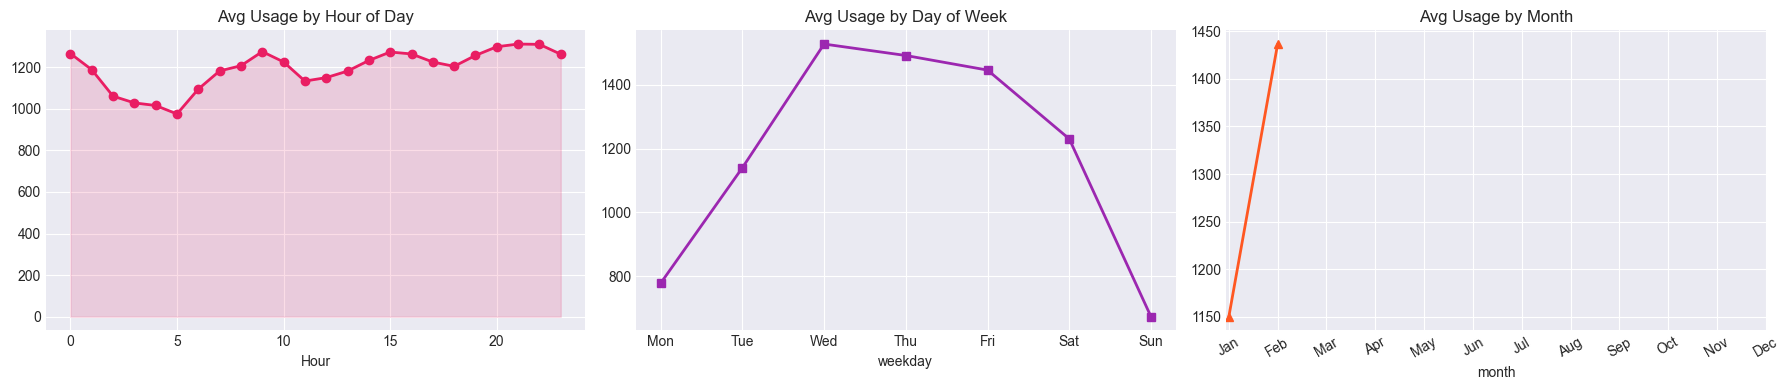

In [5]:
ts = train.copy()
ts["hour"]    = ts["timestamp"].dt.hour
ts["weekday"] = ts["timestamp"].dt.dayofweek
ts["month"]   = ts["timestamp"].dt.month

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

ts.groupby("hour")["meter_reading"].mean().plot(
    ax=axes[0], marker="o", color="#E91E63", linewidth=2)
axes[0].fill_between(range(24),
    ts.groupby("hour")["meter_reading"].mean().values, alpha=0.15, color="#E91E63")
axes[0].set_title("Avg Usage by Hour of Day")
axes[0].set_xlabel("Hour")

day_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
ts.groupby("weekday")["meter_reading"].mean().plot(
    ax=axes[1], marker="s", color="#9C27B0", linewidth=2)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names)
axes[1].set_title("Avg Usage by Day of Week")

ts.groupby("month")["meter_reading"].mean().plot(
    ax=axes[2], marker="^", color="#FF5722", linewidth=2)
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                          "Jul","Aug","Sep","Oct","Nov","Dec"], rotation=30)
axes[2].set_title("Avg Usage by Month")

plt.tight_layout()
plt.show()

## 5 — Seasonal Decomposition (Building 0, Electricity)

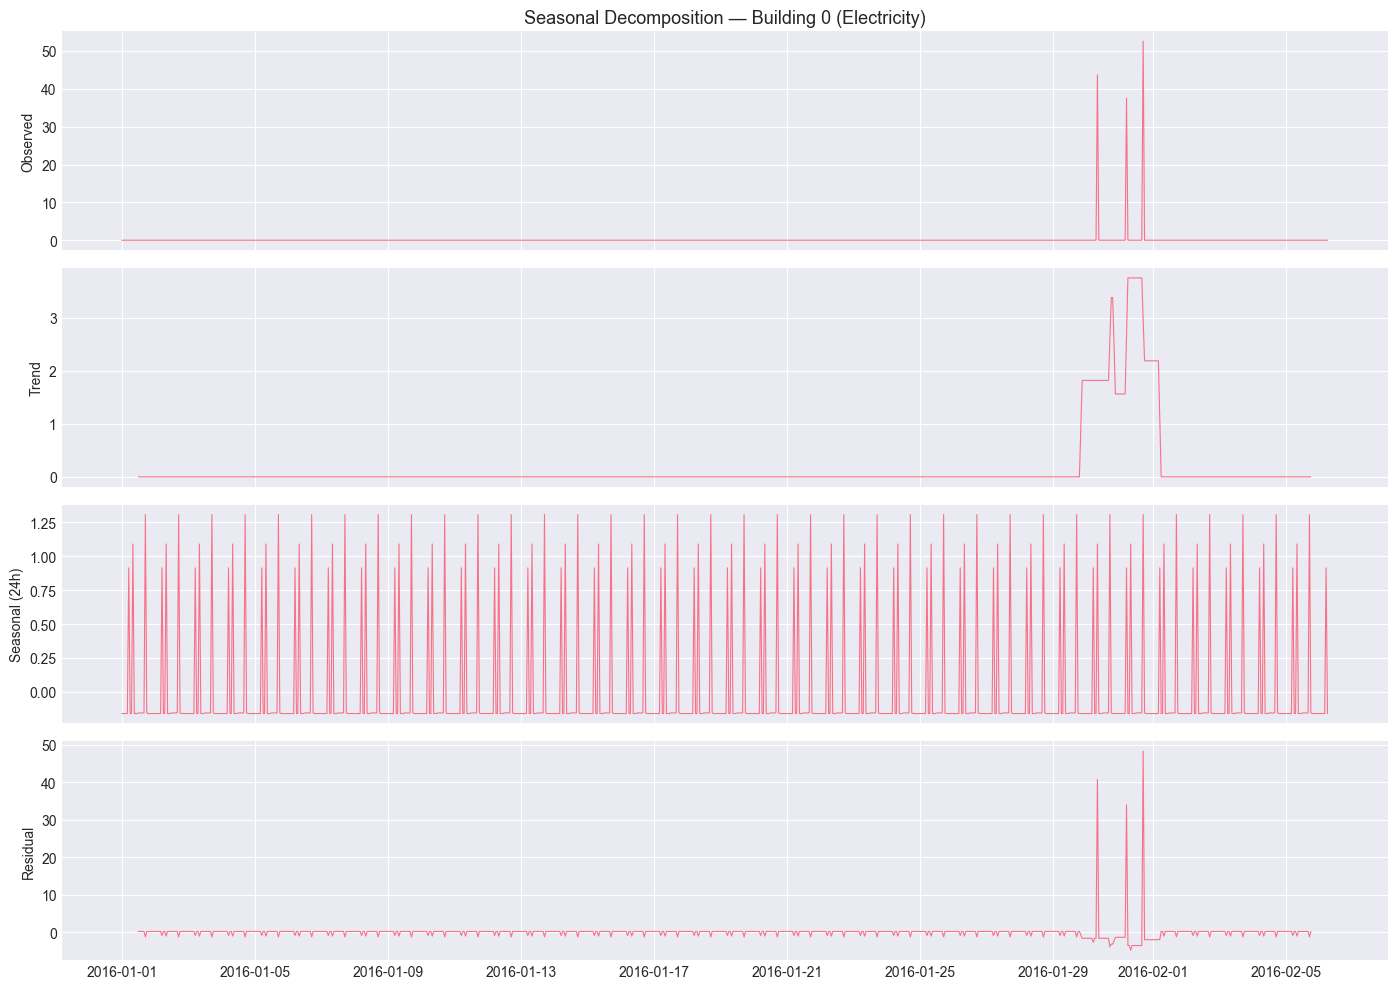

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

bld0 = (train[(train["building_id"] == 0) & (train["meter"] == 0)]
        .set_index("timestamp")["meter_reading"]
        .resample("H").mean()
        .fillna(method="ffill")
        .iloc[:24*60])     # 60 days

# Only decompose if enough data
if len(bld0) >= 48:
    result = seasonal_decompose(bld0, model="additive", period=24)
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    for ax, comp, label in zip(axes,
        [bld0, result.trend, result.seasonal, result.resid],
        ["Observed", "Trend", "Seasonal (24h)", "Residual"]):
        ax.plot(comp, linewidth=0.8)
        ax.set_ylabel(label, fontsize=10)
    axes[0].set_title("Seasonal Decomposition — Building 0 (Electricity)", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data for decomposition.")

## 6 — Weather Variable Analysis

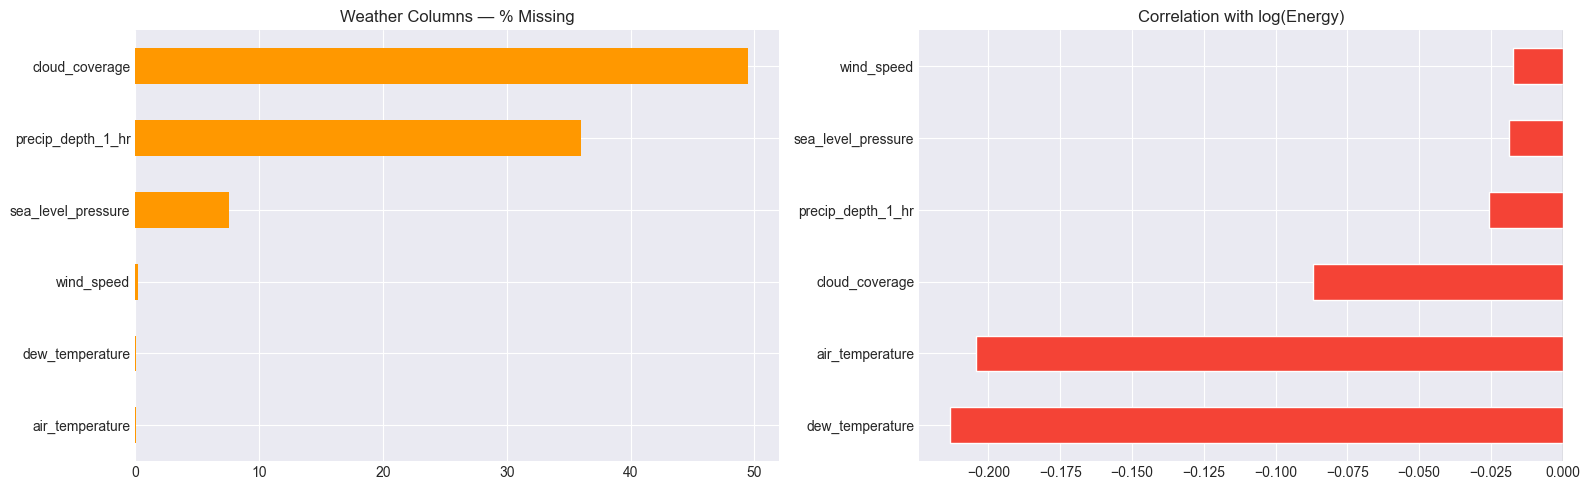

In [7]:
sample = train.sample(60_000, random_state=42)
sample = sample.merge(meta[["building_id","site_id"]], on="building_id")
sample = sample.merge(weather, on=["site_id","timestamp"], how="left")
sample["log_reading"] = np.log1p(sample["meter_reading"])

weather_cols = ["air_temperature","dew_temperature","cloud_coverage",
                "sea_level_pressure","wind_speed","precip_depth_1_hr"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# % missing
miss = weather[weather_cols].isnull().mean() * 100
miss[miss > 0].sort_values().plot(kind="barh", ax=axes[0], color="#FF9800")
axes[0].set_title("Weather Columns — % Missing", fontsize=12)

# Correlation with log(energy)
corr = (sample[weather_cols + ["log_reading"]]
        .corr()["log_reading"].drop("log_reading").sort_values())
colors = ["#F44336" if v < 0 else "#4CAF50" for v in corr.values]
corr.plot(kind="barh", ax=axes[1], color=colors, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlation with log(Energy)", fontsize=12)

plt.tight_layout()
plt.show()

## 7 — Outlier / Anomaly Detection (IQR Method)

Outlier rows : 58,841 (2.94%)


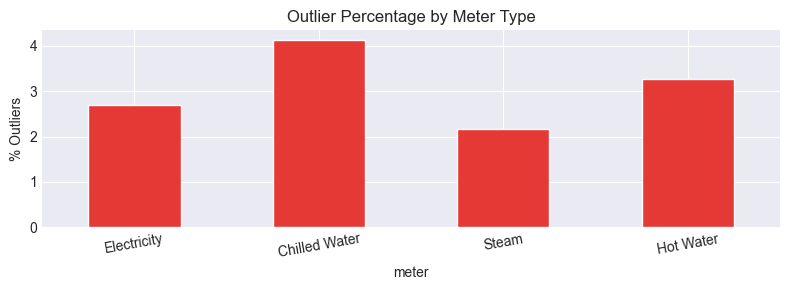

In [8]:
# Flag outliers per building+meter using IQR
q1  = train.groupby(["building_id","meter"])["meter_reading"].transform("quantile", 0.25)
q3  = train.groupby(["building_id","meter"])["meter_reading"].transform("quantile", 0.75)
iqr = q3 - q1

train["is_outlier"] = (
    (train["meter_reading"] < (q1 - 1.5 * iqr)) |
    (train["meter_reading"] > (q3 + 1.5 * iqr))
)

print(f"Outlier rows : {train['is_outlier'].sum():,} "
      f"({train['is_outlier'].mean()*100:.2f}%)")

# Show outlier density by meter
out_by_meter = train.groupby("meter")["is_outlier"].mean() * 100
fig, ax = plt.subplots(figsize=(8, 3))
out_by_meter.rename(index=METER_LABELS).plot(
    kind="bar", ax=ax, color="#E53935", edgecolor="white", width=0.5)
ax.set_title("Outlier Percentage by Meter Type", fontsize=12)
ax.set_ylabel("% Outliers")
ax.tick_params(axis="x", rotation=10)
plt.tight_layout()
plt.show()

## 8 — Full Correlation Heatmap (Merged Features)

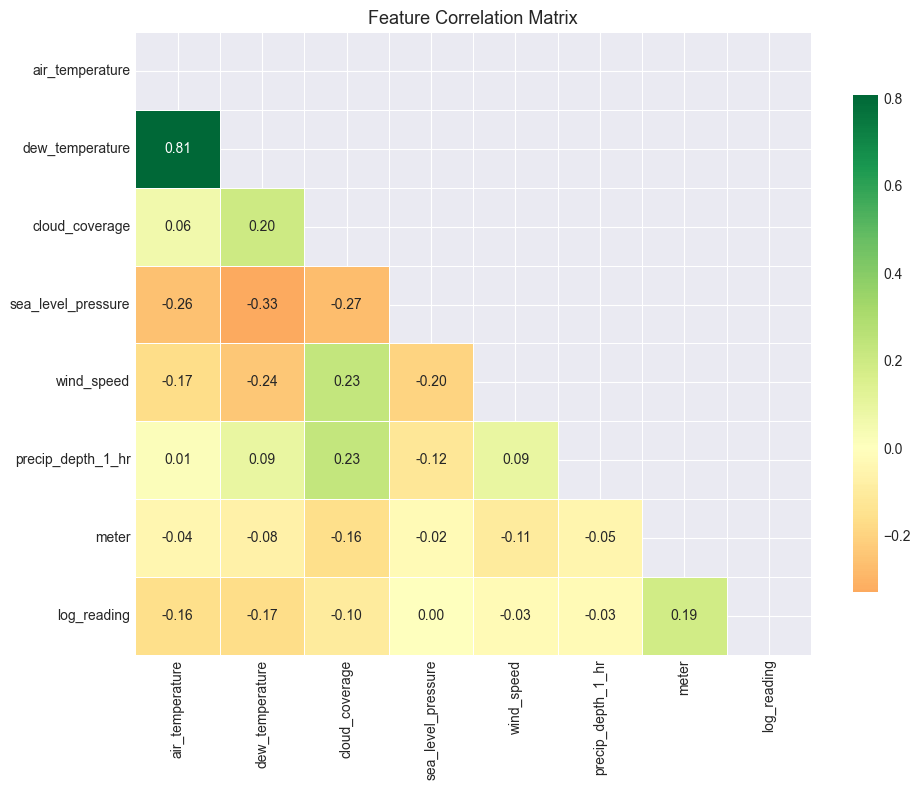

In [9]:
corr_df = sample[weather_cols + ["meter","log_reading"]].dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, ax=ax,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.show()

## 9 — EDA Summary / Key Findings

| Finding | Implication |
|---------|-------------|
| ~8.5% zeros in electricity meter | Flag and exclude from model training |
| Strong 24-h / 7-day cycles | Lag features (1h, 24h, 168h) are essential |
| Air & dew temperature have highest correlation with energy | Top features |
| `cloud_coverage` and `sea_level_pressure` have high missing % | Use interpolation, not ffill |
| Seasonal summer peak visible | Month + cyclic encoding needed |
| Outlier rate varies by meter type | Clip or Winsorize target before training |
| Building size (`square_feet`) correlates positively | Keep in feature set |
| `primary_use` causes large mean-shift between building types | One-hot encode |

➡ Proceed to `feature_engineering.ipynb` for the full ML pipeline.
